# 01 · Baseline profile and deposited-data audit

Manuscript **PONE-D-26-16201** — revision analyses.

Produces the numbers for:

| Manuscript element | What this notebook computes |
|---|---|
| Deposited-data profile | events, users, courses and traces present in each deposited faculty-role partition |
| Table: activity mix | activity-class shares by faculty and role |
| Case-notion subsection | courses per user; trace-length statistics under both notions |
| Table: deduplication | duplicate counts, **with the assignment bug fixed** |
| R2 clustering ask | Jensen–Shannon distance + hierarchical clustering of faculties |

> **Important coverage limitation.** The deposited role-partition CSVs are
> already restricted to the analysis window before 26 June 2023. They therefore
> cannot be used to calculate the percentage of the original all-role export
> retained or discarded by the date cutoff. In particular, a student-partition
> count must not be divided by an all-role raw-export count. Exact temporal
> retention/discard proportions require the original unfiltered exports (or
> role-matched pre-filter counts). This notebook deliberately does **not**
> manufacture that percentage.


## 1. Setup

Run this section first. It installs dependencies and downloads the deposit from
figshare into the Colab VM.

**Runtime:** Runtime &rarr; Change runtime type &rarr; **High-RAM** if available.
The largest faculty file (FIF, 1.3 GB on disk) needs roughly 6 GB once loaded.

In [1]:

!pip install -q pm4py==2.7.23.3 statsmodels 2>/dev/null
import os
os.environ["TQDM_DISABLE"] = "1"

import warnings, sys, json, time, gc, random
warnings.filterwarnings("ignore")
import pandas as pd, numpy as np

print("Python ", sys.version.split()[0])
print("pandas ", pd.__version__)
import pm4py; print("pm4py  ", pm4py.__version__)


try:
    import psutil
    gb = psutil.virtual_memory().total / 1e9
    print(f"RAM    {gb:.1f} GB")
    if gb < 20:
        print("\n  NOTE: standard runtime. FIF and FTE may run out of memory.")
        print("  Runtime -> Change runtime type -> High-RAM is recommended.")
except Exception:
    pass

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 46.5 MB/s eta 0:00:00
Python  3.13.15
pandas  2.2.3




  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




pm4py   2.7.23.3
RAM    13.6 GB

  NOTE: standard runtime. FIF and FTE may run out of memory.
  Runtime -> Change runtime type -> High-RAM is recommended.


In [2]:




import requests, os, pathlib

ARTICLE = "28341992"
DATA_DIR = "/content/data"
pathlib.Path(DATA_DIR).mkdir(parents=True, exist_ok=True)

meta = requests.get(f"https://api.figshare.com/v2/articles/{ARTICLE}", timeout=60).json()
print(f"{meta['title']}  (v{meta.get('version','?')})")
print(f"{len(meta['files'])} files, {meta['size']/1e9:.2f} GB total\n")

FILES = {}
for f in meta["files"]:
    FILES[f["name"]] = f["download_url"]
    print(f"  {f['name']:<32} {f['size']/1e6:>8.1f} MB")


FACULTIES = ["FEB", "FIF", "FIK", "FIT", "FKB", "FRI", "FTE"]
missing = [f"{fac}_{role}.csv" for fac in FACULTIES
           for role in ("Student", "Lecturer") if f"{fac}_{role}.csv" not in FILES]
if missing:
    print("\n  MISSING FROM DEPOSIT:")
    for m in missing:
        print(f"    {m}")
    print("\n  Analyses for these partitions will be skipped.")


def fetch(name):
    """Download one file if not already present. Returns local path or None."""
    if name not in FILES:
        return None
    dest = os.path.join(DATA_DIR, name)
    if os.path.exists(dest) and os.path.getsize(dest) > 1_000_000:
        return dest
    print(f"downloading {name} ...", flush=True)
    with requests.get(FILES[name], stream=True, timeout=1800) as r:
        r.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in r.iter_content(1 << 22):
                fh.write(chunk)
    print(f"  -> {os.path.getsize(dest)/1e6:.0f} MB")
    return dest

Process Mining in CeLOE  (v2)
7 files, 5.21 GB total

  FIF_Student.csv                    1314.5 MB
  FIT_Student.csv                     303.8 MB
  FIK_Student.csv                     417.6 MB
  FEB_Student.csv                     881.4 MB
  FTE_Student.csv                     874.3 MB
  FRI_Student.csv                     753.6 MB
  FKB_Student.csv                     666.4 MB

  MISSING FROM DEPOSIT:
    FEB_Lecturer.csv
    FIF_Lecturer.csv
    FIK_Lecturer.csv
    FIT_Lecturer.csv
    FKB_Lecturer.csv
    FRI_Lecturer.csv
    FTE_Lecturer.csv

  Analyses for these partitions will be skipped.


In [3]:



USECOLS = ["id", "eventname", "component", "action", "target", "crud",
           "edulevel", "userid", "courseid", "timecreated", "event"]
DTYPES = {"id": "int64", "eventname": "category", "component": "category",
          "action": "category", "target": "category", "crud": "category",
          "edulevel": "int8", "userid": "int32", "courseid": "int32",
          "event": "category"}

CUTOFF = "2023-06-26"


def load(faculty, role, apply_dedup=True, cols=None):
    """Load one faculty-role partition.

    apply_dedup fixes the defect found during revision: the original notebooks
    called df.drop_duplicates() WITHOUT assignment, so duplicates were counted
    and reported but never removed from the working data.
    """
    name = f"{faculty}_{role}.csv"
    path = fetch(name)
    if path is None:
        print(f"  [skip] {name} not in deposit")
        return None
    use = cols or USECOLS
    df = pd.read_csv(path, index_col=0, usecols=lambda c: c in use or c == "Unnamed: 0",
                     dtype={k: v for k, v in DTYPES.items() if k in use},
                     parse_dates=["timecreated"] if "timecreated" in use else None)
    n_raw = len(df)
    n_dup = int(df.duplicated().sum())
    if apply_dedup and n_dup:
        df = df.drop_duplicates()
    df.attrs["n_raw"] = n_raw
    df.attrs["n_dup"] = n_dup
    df.attrs["faculty"] = faculty
    df.attrs["role"] = role
    return df


def add_case(df, notion):
    """notion is 'user' or 'course'."""
    if notion == "user":
        df["case"] = df["userid"].astype(str)
    else:
        df["case"] = df["userid"].astype(str) + "_" + df["courseid"].astype(str)
    return df


def to_log(df, notion, sample=None, seed=42, max_len=None):
    """Build a pm4py EventLog. sample caps the number of traces."""
    d = add_case(df, notion)
    if max_len:
        keep = d.groupby("case").size()
        d = d[d["case"].isin(keep[keep <= max_len].index)]
    if sample:
        random.seed(seed)
        cases = sorted(d["case"].unique())
        d = d[d["case"].isin(set(random.sample(cases, min(sample, len(cases)))))]
    ldf = (d[["case", "event", "timecreated"]]
           .rename(columns={"case": "case:concept:name", "event": "concept:name",
                            "timecreated": "time:timestamp"})
           .sort_values(["case:concept:name", "time:timestamp"])
           .reset_index(drop=True))

    ldf["case:concept:name"] = ldf["case:concept:name"].astype(str)
    ldf["concept:name"] = ldf["concept:name"].astype(str)
    return pm4py.convert_to_event_log(ldf), ldf


def save(obj, name):
    """Persist a result table and offer it for download."""
    if isinstance(obj, pd.DataFrame):
        obj.to_csv(f"/content/{name}.csv", index=False)
    else:
        json.dump(obj, open(f"/content/{name}.json", "w"), indent=1)
    print(f"saved /content/{name}")

## 2. Per-partition profile

Loops over all seven faculties and both roles. Skips partitions absent from the
deposit rather than failing.

In [4]:
ROLES = ["Student", "Lecturer"]
rows, act_shares = [], {}

for fac in FACULTIES:
    for role in ROLES:
        df = load(fac, role)
        if df is None:
            continue
        df = add_case(df, "course")
        tl_user = df.groupby("userid").size()
        tl_course = df.groupby("case").size()
        cpu = df.groupby("userid")["courseid"].nunique()

        rows.append(dict(
            faculty=fac, role=role,
            events=len(df),
            dup_removed=df.attrs["n_dup"],
            users=df["userid"].nunique(),
            courses=df["courseid"].nunique(),
            activities=df["event"].nunique(),
            first=str(df["timecreated"].min().date()),
            last=str(df["timecreated"].max().date()),
            traces_user=len(tl_user),
            len_user_mean=round(tl_user.mean(), 1),
            len_user_med=int(tl_user.median()),
            len_user_max=int(tl_user.max()),
            traces_course=len(tl_course),
            len_course_mean=round(tl_course.mean(), 1),
            len_course_med=int(tl_course.median()),
            len_course_max=int(tl_course.max()),
            courses_per_user_mean=round(cpu.mean(), 2),
            pct_users_multicourse=round(100 * (cpu > 1).mean(), 1),
        ))
        act_shares[f"{fac}_{role}"] = (df["event"].value_counts(normalize=True) * 100)
        print(f"{fac} {role:<8} {len(df):>10,} events  "
              f"{df['userid'].nunique():>5,} users  "
              f"{round(cpu.mean(),2):>5} courses/user  "
              f"{round(100*(cpu>1).mean(),1):>5}% multi-course", flush=True)
        del df; gc.collect()

profile = pd.DataFrame(rows)
save(profile, "01_profile")
profile

downloading FEB_Student.csv ...
  -> 881 MB
FEB Student   6,172,787 events  3,794 users   5.41 courses/user   91.1% multi-course
  [skip] FEB_Lecturer.csv not in deposit
downloading FIF_Student.csv ...
  -> 1314 MB
FIF Student   9,240,852 events  3,679 users   6.17 courses/user   92.6% multi-course
  [skip] FIF_Lecturer.csv not in deposit
downloading FIK_Student.csv ...
  -> 418 MB
FIK Student   2,786,128 events  4,091 users   5.56 courses/user   89.0% multi-course
  [skip] FIK_Lecturer.csv not in deposit
downloading FIT_Student.csv ...
  -> 304 MB
FIT Student   2,097,109 events  2,413 users   5.74 courses/user   93.1% multi-course
  [skip] FIT_Lecturer.csv not in deposit
downloading FKB_Student.csv ...
  -> 666 MB
FKB Student   4,555,094 events  4,018 users    6.0 courses/user   92.9% multi-course
  [skip] FKB_Lecturer.csv not in deposit
downloading FRI_Student.csv ...
  -> 754 MB
FRI Student   5,311,795 events  4,665 users   5.53 courses/user   93.3% multi-course
  [skip] FRI_Lecture

,faculty,role,events,dup_removed,users,courses,activities,first,last,traces_user,len_user_mean,len_user_med,len_user_max,traces_course,len_course_mean,len_course_med,len_course_max,courses_per_user_mean,pct_users_multicourse
0,FEB,Student,6172787,148,3794,544,57,2023-03-21,2023-06-25,3794,1627.0,1560,7577,20512,300.9,263,2890,5.41,91.1
1,FIF,Student,9240852,6599,3679,623,95,2023-03-21,2023-06-25,3679,2511.8,1808,20510,22684,407.4,234,7596,6.17,92.6
2,FIK,Student,2786128,147,4091,902,64,2023-03-21,2023-06-25,4091,681.0,570,5598,22751,122.5,81,2322,5.56,89.0
3,FIT,Student,2097109,0,2413,481,70,2023-03-21,2023-06-25,2413,869.1,770,5167,13856,151.4,98,1794,5.74,93.1
4,FKB,Student,4555094,0,4018,674,57,2023-03-21,2023-06-25,4018,1133.7,1037,6315,24104,189.0,153,1937,6.00,92.9
5,FRI,Student,5311795,202,4665,890,62,2023-03-23,2023-06-25,4665,1138.6,1050,5394,25805,205.8,141,2272,5.53,93.3
6,FTE,Student,6032292,84,3680,668,66,2023-03-23,2023-06-25,3680,1639.2,1666,10137,22412,269.2,220,2931,6.09,92.5


## 3. Activity-class shares

Maps raw Moodle event names onto the six classes used in the manuscript table.
Adjust `CLASSES` if your class definitions differ.

In [5]:
CLASSES = {
    "Grading":       ["user_graded", "grading_form_viewed", "grade_"],
    "Quiz review":   ["attempt_reviewed", "attempt_summary_viewed"],
    "Quiz attempt":  ["attempt_viewed", "attempt_started", "attempt_submitted"],
    "Course access": ["course_viewed", "course_module_viewed"],
    "Assignment":    ["mod_assign", "assessable_submitted", "submission_"],
}


def classify(ev):
    for cls, keys in CLASSES.items():
        if any(k in ev for k in keys):
            return cls
    return "Other"


mix = {}
for key, s in act_shares.items():
    g = s.groupby(s.index.map(classify)).sum()
    mix[key] = g

mixdf = pd.DataFrame(mix).T.fillna(0).round(1)
for col in ["Grading", "Quiz review", "Quiz attempt", "Course access", "Assignment", "Other"]:
    if col not in mixdf:
        mixdf[col] = 0.0
mixdf = mixdf[["Grading", "Quiz review", "Quiz attempt", "Course access", "Assignment", "Other"]]
save(mixdf.reset_index().rename(columns={"index": "faculty_role"}), "01_activity_mix")
mixdf

saved /content/01_activity_mix


event,Grading,Quiz review,Quiz attempt,Course access,Assignment,Other
FEB_Student,0.2,0.0,43.2,42.6,4.5,9.5
FIF_Student,0.3,0.0,52.1,33.1,3.2,11.3
FIK_Student,0.2,0.0,18.4,53.9,10.3,17.3
FIT_Student,0.2,0.0,36.4,45.9,6.9,10.6
FKB_Student,0.2,0.0,27.5,50.6,6.5,15.2
FRI_Student,0.2,0.0,55.1,33.8,4.6,6.3
FTE_Student,0.3,0.0,40.3,42.2,6.2,11.0


### Heatmap (Reviewer 2 asked for this)

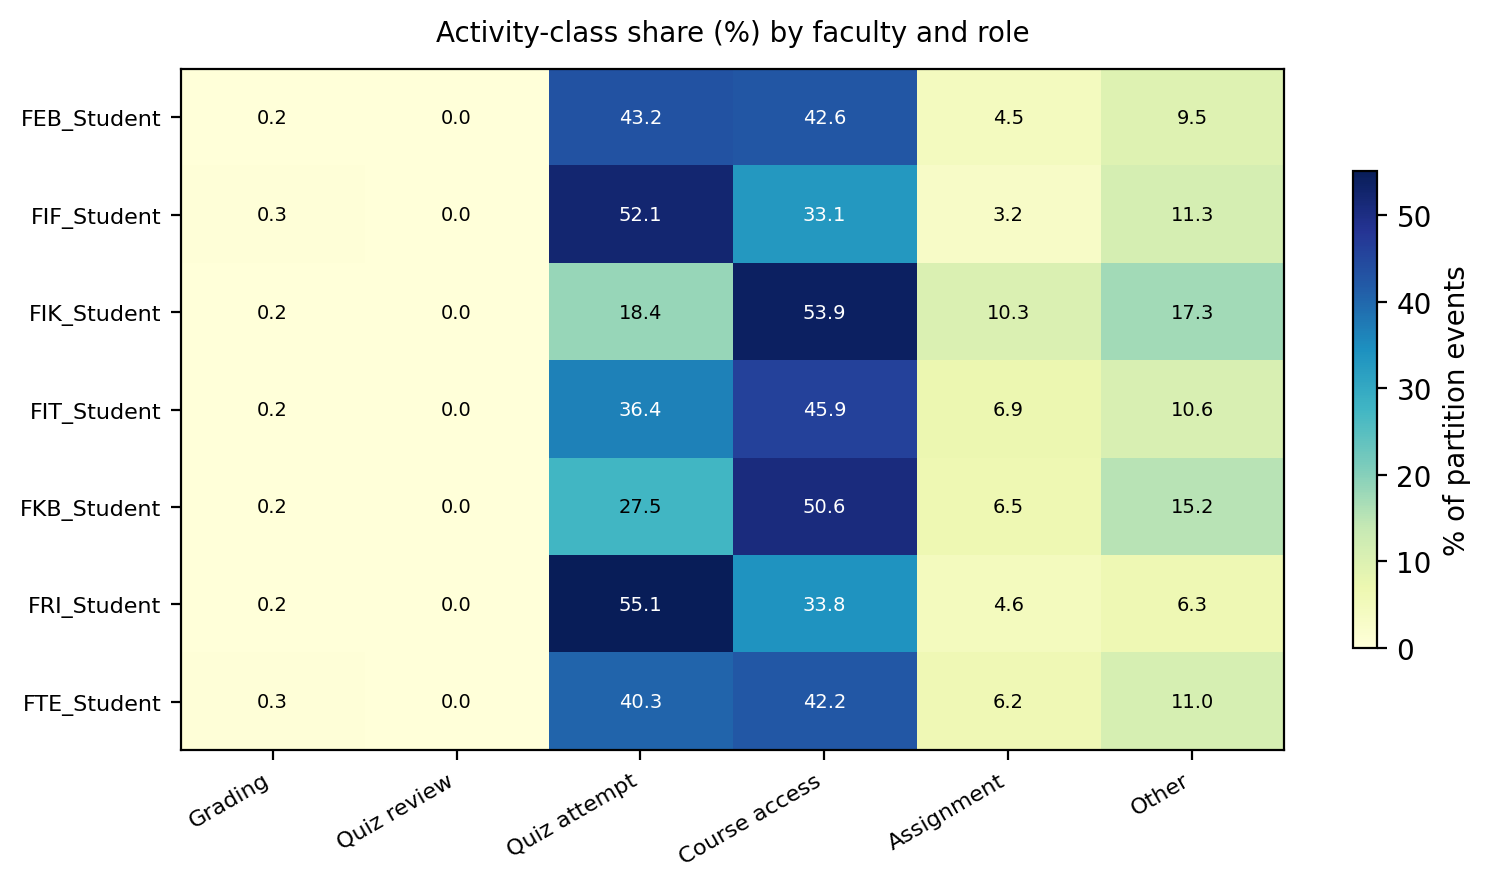

saved /content/fig_activity_heatmap.png  (300 dpi, PLOS-compliant)


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 0.42 * len(mixdf) + 1.6), dpi=200)
im = ax.imshow(mixdf.values, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(len(mixdf.columns)))
ax.set_xticklabels(mixdf.columns, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(mixdf)))
ax.set_yticklabels(mixdf.index, fontsize=8)
for i in range(mixdf.shape[0]):
    for j in range(mixdf.shape[1]):
        v = mixdf.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7,
                color="white" if v > mixdf.values.max() * 0.55 else "black")
ax.set_title("Activity-class share (%) by faculty and role", fontsize=10, pad=10)
fig.colorbar(im, ax=ax, shrink=0.7, label="% of partition events")
plt.tight_layout()
plt.savefig("/content/fig_activity_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("saved /content/fig_activity_heatmap.png  (300 dpi, PLOS-compliant)")

## 4. Faculty clustering

Jensen–Shannon **distance** between full activity distributions, followed by
average-linkage hierarchical clustering. This answers Reviewer 2's request for
clustering and provides an effect-size-style description of cross-faculty
distributional differences rather than a significance test dominated by the
very large event counts.

Average linkage is used because it accepts a general dissimilarity matrix;
Ward linkage assumes Euclidean feature-space geometry and is therefore not
used directly on the precomputed Jensen–Shannon distance matrix.



=== Student: pairwise Jensen-Shannon divergence ===
       FEB    FIF    FIK    FIT    FKB    FRI    FTE
FEB  0.000  0.177  0.288  0.128  0.170  0.148  0.141
FIF  0.177  0.000  0.392  0.225  0.296  0.168  0.181
FIK  0.288  0.392  0.000  0.208  0.141  0.365  0.252
FIT  0.128  0.225  0.208  0.000  0.132  0.178  0.095
FKB  0.170  0.296  0.141  0.132  0.000  0.272  0.179
FRI  0.148  0.168  0.365  0.178  0.272  0.000  0.154
FTE  0.141  0.181  0.252  0.095  0.179  0.154  0.000
  2 clusters: FEB=C2, FIF=C2, FIK=C1, FIT=C2, FKB=C1, FRI=C2, FTE=C2
  3 clusters: FEB=C2, FIF=C3, FIK=C1, FIT=C2, FKB=C1, FRI=C2, FTE=C2


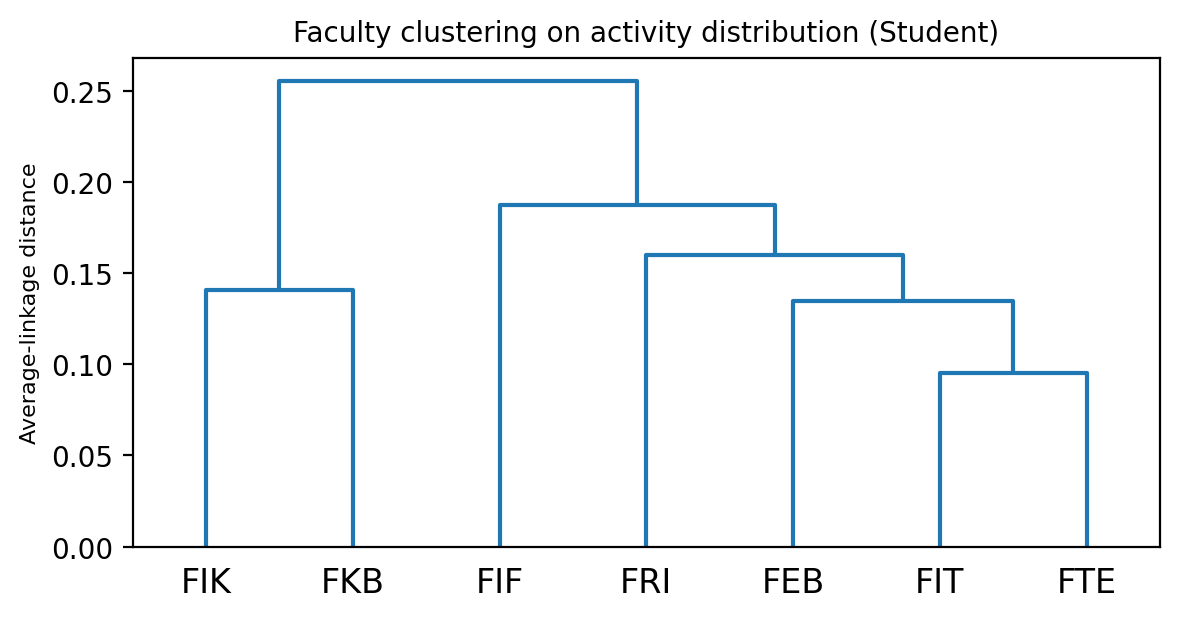

[skip] Lecturer: only 0 partitions available


In [7]:
from scipy.spatial.distance import jensenshannon, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

for role in ["Student", "Lecturer"]:
    keys = [k for k in act_shares if k.endswith(role)]
    if len(keys) < 3:
        print(f"[skip] {role}: only {len(keys)} partitions available")
        continue
    allacts = sorted(set().union(*[set(act_shares[k].index) for k in keys]))
    M = np.array([[act_shares[k].get(a, 0.0) for a in allacts] for k in keys])
    M = M / M.sum(axis=1, keepdims=True)

    D = np.zeros((len(keys), len(keys)))
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            D[i, j] = D[j, i] = jensenshannon(M[i], M[j], base=2)

    print(f"\n=== {role}: pairwise Jensen-Shannon divergence ===")
    print(pd.DataFrame(D, index=[k[:3] for k in keys],
                       columns=[k[:3] for k in keys]).round(3).to_string())

    Z = linkage(squareform(D, checks=False), method="average")
    for ncl in (2, 3):
        lab = fcluster(Z, ncl, criterion="maxclust")
        print(f"  {ncl} clusters: " +
              ", ".join(f"{k[:3]}=C{l}" for k, l in zip(keys, lab)))

    fig, ax = plt.subplots(figsize=(6, 3.2), dpi=200)
    dendrogram(Z, labels=[k[:3] for k in keys], ax=ax, color_threshold=0)
    ax.set_title(f"Faculty clustering on activity distribution ({role})", fontsize=10)
    ax.set_ylabel("Average-linkage distance", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"/content/fig_cluster_{role.lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 5. LaTeX-friendly output

Emits table rows that can be copied into the manuscript after the notebook has
been executed. The first block is a **deposited-data profile**, not a temporal
retention table.


In [8]:
print("% ---- deposited-data profile (NOT a temporal-retention table) ----")
print("% The role-partition CSVs are already filtered to < 2023-06-26.")
print("% Do NOT divide a Student/Lecturer partition count by an all-role raw-export count.")
print("% Exact retained/discarded percentages require the original unfiltered exports.")

for fac in FACULTIES:
    for role in ROLES:
        sub = profile[(profile.faculty == fac) & (profile.role == role)]
        if not len(sub):
            continue
        r = sub.iloc[0]
        print(f"{fac} {role.lower()} & {r.events:,} & {r.users:,} & "
              f"{r.courses:,} & {r.traces_user:,} & {r.traces_course:,} \\")

print("\n% ---- activity mix table body (Table: tab:activitymix) ----")
for idx, row in mixdf.iterrows():
    fac, role = idx.rsplit("_", 1)
    cells = " & ".join(f"{v:.1f}" if v > 0 else "--" for v in row.values)
    print(f"{fac} {role.lower()} & {cells} \\")


% ---- deposited-data profile (NOT a temporal-retention table) ----
% The role-partition CSVs are already filtered to < 2023-06-26.
% Do NOT divide a Student/Lecturer partition count by an all-role raw-export count.
% Exact retained/discarded percentages require the original unfiltered exports.
FEB student & 6,172,787 & 3,794 & 544 & 3,794 & 20,512 \
FIF student & 9,240,852 & 3,679 & 623 & 3,679 & 22,684 \
FIK student & 2,786,128 & 4,091 & 902 & 4,091 & 22,751 \
FIT student & 2,097,109 & 2,413 & 481 & 2,413 & 13,856 \
FKB student & 4,555,094 & 4,018 & 674 & 4,018 & 24,104 \
FRI student & 5,311,795 & 4,665 & 890 & 4,665 & 25,805 \
FTE student & 6,032,292 & 3,680 & 668 & 3,680 & 22,412 \

% ---- activity mix table body (Table: tab:activitymix) ----
FEB student & 0.2 & -- & 43.2 & 42.6 & 4.5 & 9.5 \
FIF student & 0.3 & -- & 52.1 & 33.1 & 3.2 & 11.3 \
FIK student & 0.2 & -- & 18.4 & 53.9 & 10.3 & 17.3 \
FIT student & 0.2 & -- & 36.4 & 45.9 & 6.9 & 10.6 \
FKB student & 0.2 & -- & 27.5 & 50.